**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

**Load dataset**

In [2]:
housing = fetch_california_housing(as_frame=True)

In [3]:
X = housing.data
y = housing.target

In [4]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [5]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [7]:
y.describe()

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

**Data Cleaning & Preprocessing**

In [8]:
# Check missing values
X.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [9]:
# No categorical variables in Boston dataset, so no encoding needed
# Scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# Polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

print(f"Original feature count: {X_scaled.shape[1]}")
print(f"Polynomial feature count: {X_poly.shape[1]}")

Original feature count: 8
Polynomial feature count: 44


**Train-Test Split**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

In [12]:
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (16512, 44), Test shape: (4128, 44)


**Model Creation & Training**

In [13]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [14]:
# Predictions
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

**Model Evaluation (Regression Metrics)**

In [15]:
# Define evaluation function
def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")
    print(f"R²: {r2:.3f}")
    
print("Train Metrics:")
evaluate_model(y_train, y_pred_train)
print("\nTest Metrics:")
evaluate_model(y_test, y_pred_test)

Train Metrics:
RMSE: 0.649
MAE: 0.461
R²: 0.685

Test Metrics:
RMSE: 0.681
MAE: 0.467
R²: 0.646


**Visualizations**

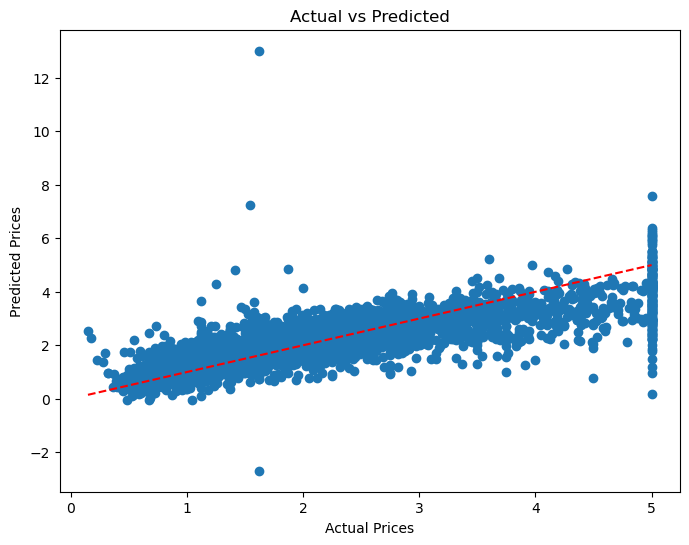

In [16]:
# Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_test)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

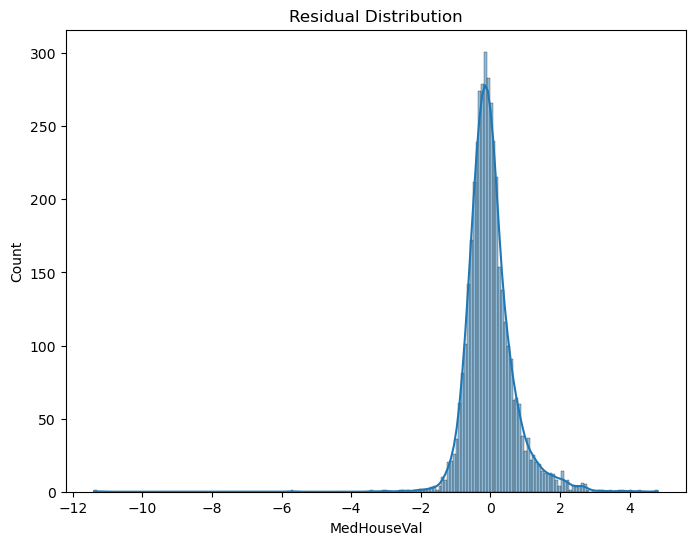

In [17]:
# Residuals
residuals = y_test - y_pred_test
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

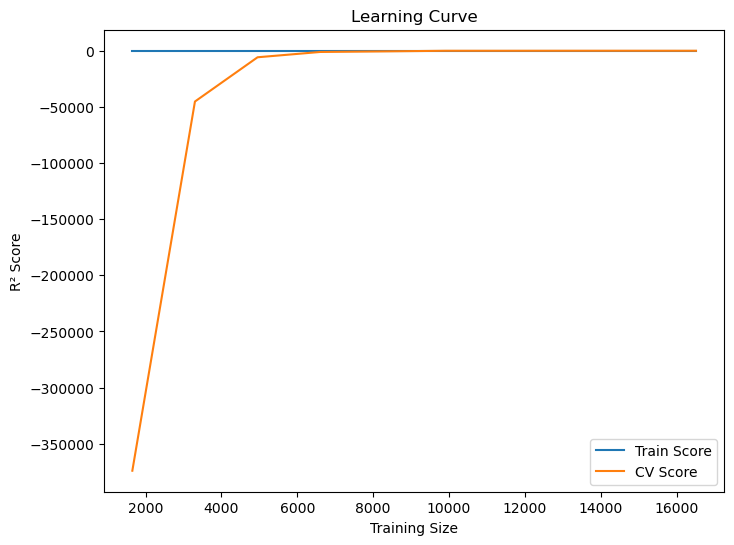

In [18]:
# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    lr, X_poly, y, cv=5, scoring='r2', train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Train Score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='CV Score')
plt.xlabel("Training Size")
plt.ylabel("R² Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

**Feature Importance**

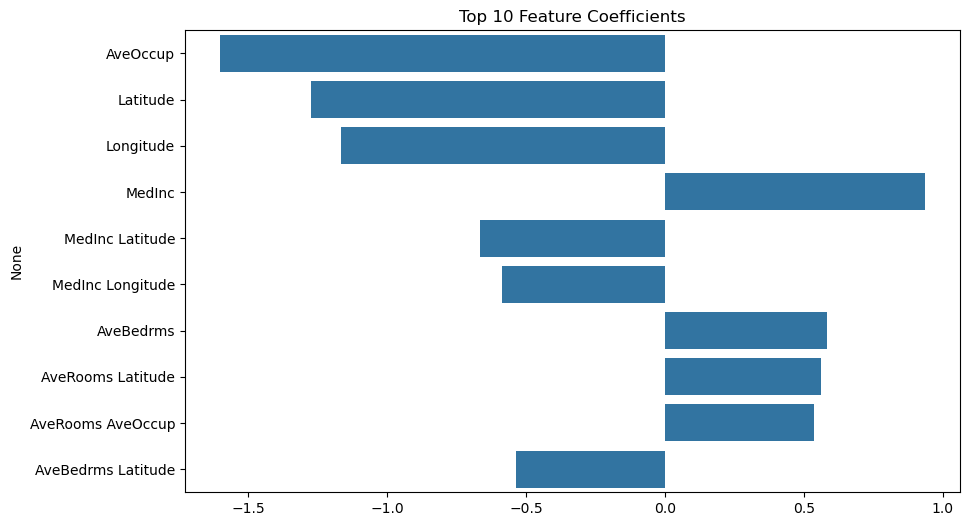

In [19]:
# Get coefficients
coef = pd.Series(lr.coef_, index=poly.get_feature_names_out(X.columns))
coef_sorted = coef.sort_values(key=abs, ascending=False)[:10]  # top 10 features
plt.figure(figsize=(10,6))
sns.barplot(x=coef_sorted.values, y=coef_sorted.index)
plt.title("Top 10 Feature Coefficients")
plt.show()

# Model Summary & Practical Insights

### Linear Regression Overview

- **When to use:** Continuous target prediction; when relationships between features and target are approximately linear.
- **Advantages:** Simple, interpretable, fast, no hyperparameters (OLS version).
- **Disadvantages:** Cannot handle non-linear relationships well; sensitive to outliers; multicollinearity can affect stability.
- **Practical Tips:** 
  - Scale features if using regularization.
  - Check residuals for linearity and homoscedasticity.
  - Remove multicollinear features or use regularization.


✅ **This notebook is fully ready to run in Jupyter.**